### Learning objectives:
- Learn more about the CAMELS dataset ....
- Understand how to read in and explore CAMELS data
- Learn how (and why) to build and apply a simple ML model 

### Introduction

# 0. Data set-up stages

In [1]:
import pandas as pd
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

home_dir = "/scratch/hydro4/shared_data/uk_catchment_data/camels_gb_v2/"
# os.listdir(home_dir + 'Catchment_Attributes')

In [2]:
hydrologic_attributes = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_hydrologic_attributes.csv")
climatic_attributes = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_climatic_attributes.csv")
topography = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_topographic_attributes.csv")

# 1. Observations: Exploring Hydrological Diversity


Objective: 
- Introduce the data and highlight variability in relationship between mean precip and mean runoff  

Task: 
- Plot mean annual precipitation vs mean annual runoff.  

Outcomes:   
   - Generally a positive trend between mean precip and mean runoff
   - However, there is quite a large spread in values
   - Outliers: some catchments produce much more or much less runoff than expected for their rainfall.
   - Start to think about what can explain those differences

In [4]:
from shapely.geometry import Point
import contextily as ctx
from matplotlib.colors import PowerNorm

In [5]:
# Get just the gauge location information
gauge_locs = topography[['gauge_id', 'gauge_name', 'gauge_lat', 'gauge_lon']]
# Construct the geometry from the latitude and longitude using Shapely
geometry = [Point(xy) for xy in zip(topography.gauge_lon, topography.gauge_lat)]
# Create the geodataframe
# gauge_locs = topography.drop(['gauge_lon', 'gauge_lat'], axis=1)
gauge_locs_gdf = gpd.GeoDataFrame(gauge_locs, crs="EPSG:4326", geometry=geometry)
gauge_locs_gdf.head()
gauge_locs_3857 = gauge_locs_gdf.to_crs(epsg=3857)

In [6]:
merged = (gauge_locs_3857
        .merge(climatic_attributes, on="gauge_id", how="left")
        .merge(hydrologic_attributes, on="gauge_id", how="left"))

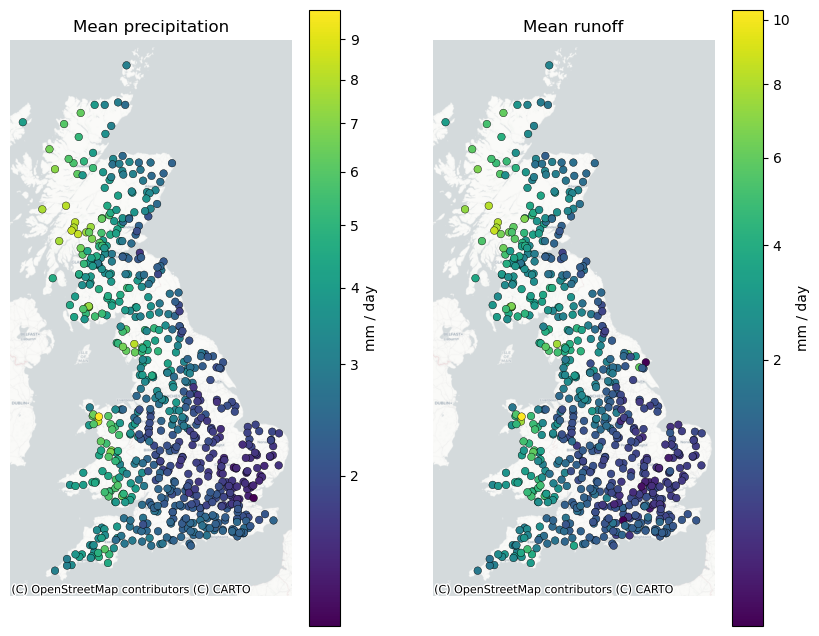

In [7]:
fig,axs=plt.subplots(ncols=2, figsize=(10,8))
merged.plot('p_mean', ax=axs[0], markersize=30, legend=True,  cmap='viridis', edgecolor='black', linewidth=0.3,
                norm=PowerNorm(gamma=0.5, vmin=merged['p_mean'].min(), vmax=merged['p_mean'].max()),
            legend_kwds={"label": "mm / day", "orientation": "vertical"})
axs[0].axis('off')
axs[0].set_title("Mean precipitation")
ctx.add_basemap(axs[0], source=ctx.providers.CartoDB.Positron)

merged.plot('q_mean', ax=axs[1], markersize=30, legend=True,  cmap='viridis', edgecolor='black', linewidth=0.3,
                norm=PowerNorm(gamma=0.5, vmin=merged['q_mean'].min(), vmax=merged['q_mean'].max()),
            legend_kwds={"label": "mm / day", "orientation": "vertical"})
axs[1].axis('off')
axs[1].set_title("Mean runoff")
ctx.add_basemap(axs[1], source=ctx.providers.CartoDB.Positron)

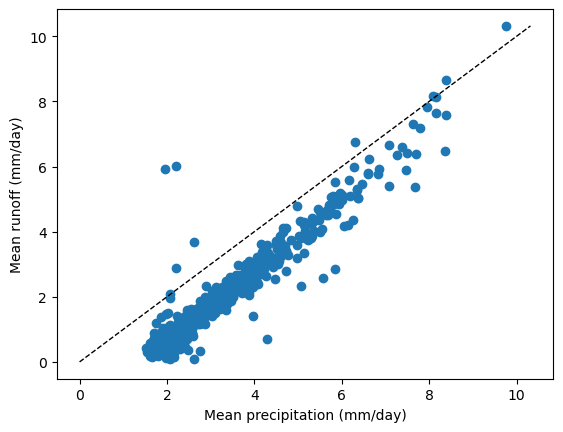

In [8]:
plt.scatter(climatic_attributes['p_mean'], hydrologic_attributes['q_mean'])
plt.xlabel('Mean precipitation (mm/day)')
plt.ylabel('Mean runoff (mm/day)')

max_val = max(climatic_attributes['p_mean'].max(), hydrologic_attributes['q_mean'].max())
plt.plot([0, max_val], [0, max_val], 'k--', linewidth=1);

In [9]:
#### Runoff ratio: calculated as the ratio of mean daily discharge to mean daily precipitation

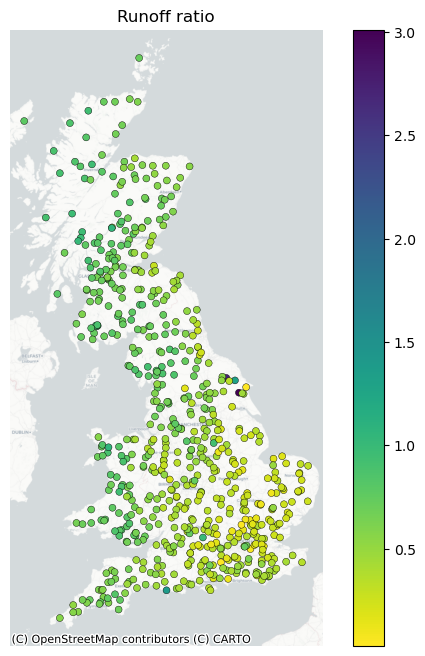

In [10]:
fig,ax=plt.subplots(figsize=(8,8))
merged.plot('runoff_ratio', ax=ax, markersize=25, legend=True,  cmap='viridis_r', edgecolor='black', linewidth=0.3,
#             norm=PowerNorm(gamma=0.4, vmin=merged['runoff_ratio'].min(), vmax=merged['runoff_ratio'].max()),
            legend_kwds={"label":"" , "orientation": "vertical"})
ax.axis('off')
ax.set_title("Runoff ratio")
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

In [11]:
# from datetime import datetime
# test = pd.read_csv(home_dir + 'Catchment_Timeseries/Hydro-Meteorological/Daily/CAMELS_GB_v2_hydromet_daily_timeseries_41014_19701001-20220930.csv')
# test.set_index('date', inplace=True)
# test = test.loc['2020-01-01 00:00:00':'2020-12-31 23:00:00']
# test=test[:100]

In [12]:
# fig,ax1=plt.subplots(figsize=(12,3))
# ax1.plot(test['discharge_vol'])
# ax2 = ax1.twinx()
# ax2.plot(test['precipitation_haduk'], color="purple")

In [13]:
# fig,ax1=plt.subplots(figsize=(12,3))
# ax1.plot(test['discharge_vol'])

# 2: Catchment Behavior: Understanding Diversity

Objective: 
- Show how catchment characteristics influence response.

Task:
- Replot the mean precipitation vs mean runoff scatter plot, but colour the points by base_flow_index
- Compare hydrographs or runoff fractions of high-BFI vs low-BFI catchments.

Outcomes:
- Introduce: Baseflow Index (BFI), hydrographs, runoff storage concepts.
- Think about how catchment features connect to observed runoff patterns 

<!-- 
“Which catchments act like sponges?”

“Which ones respond quickly to rainfall?”

“How might soils, slope, or vegetation affect these patterns?” -->


<!-- Runoff sensitivity (or flow variability) tells us how strongly a catchment responds to rainfall variability.

Two catchments can receive similar rainfall but behave very differently:

Buffered catchments (high groundwater storage)
        → rainfall variability is smoothed
        → river flows change slowly

Flashy catchments (little storage)
        → rainfall variability is amplified
        → large swings in river flow

So predicting runoff sensitivity answers the question:

Why do some catchments respond strongly to rainfall while others smooth it out? -->

In [14]:
hydrogeology = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_hydrogeology_attributes.csv")
landcover = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_landcover_attributes.csv")
soil = pd.read_csv(home_dir + 'Catchment_Attributes/CAMELS_GB_v2_soil_attributes.csv')

cols = landcover.filter(like='dwood_perc_').columns
landcover['dwood_perc_mean'] = landcover[cols].mean(axis=1)

cols = landcover.filter(like='ewood_perc_').columns
landcover['ewood_perc_mean'] = landcover[cols].mean(axis=1)

landcover['all_wood_mean'] = landcover['dwood_perc_mean'] + landcover['ewood_perc_mean']

Text(0, 0.5, 'Elevation')

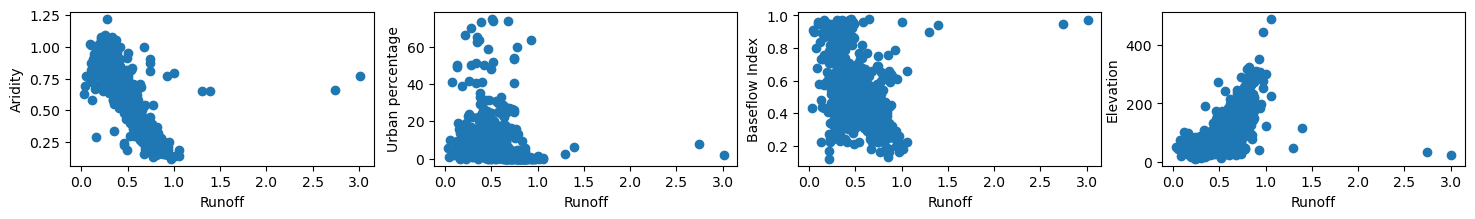

In [15]:
fig, axs = plt.subplots(ncols=4, figsize=(18,2))
# axs[0].scatter(hydrologic_attributes['q_mean'], landcover['all_wood_mean'])
axs[0].scatter(hydrologic_attributes['runoff_ratio'], climatic_attributes['aridity'])
axs[0].set_xlabel('Runoff')
axs[0].set_ylabel('Aridity')

axs[1].scatter(hydrologic_attributes['runoff_ratio'], landcover['urban_perc_2022'])
axs[1].set_xlabel('Runoff')
axs[1].set_ylabel('Urban percentage')

axs[2].scatter(hydrologic_attributes['runoff_ratio'], hydrologic_attributes['baseflow_index_ceh'])
axs[2].set_xlabel('Runoff')
axs[2].set_ylabel('Baseflow Index')

axs[3].scatter(hydrologic_attributes['runoff_ratio'], topography['dpsbar'])
axs[3].set_xlabel('Runoff')
axs[3].set_ylabel('Elevation')

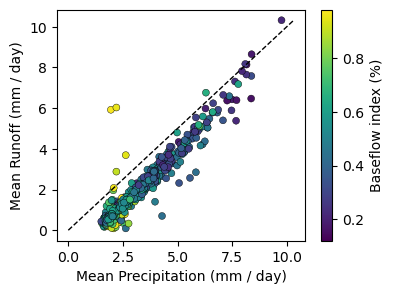

In [16]:
plt.figure(figsize=(4,3))

sc = plt.scatter(climatic_attributes['p_mean'],
                hydrologic_attributes['q_mean'],
                c=hydrologic_attributes['baseflow_index_ceh'],
                cmap='viridis', s=25, edgecolor = 'black', linewidth=0.3)

plt.xlabel('Mean Precipitation (mm / day)')
plt.ylabel('Mean Runoff (mm / day)')

plt.colorbar(sc, label='Baseflow index (%)')

max_val = max(climatic_attributes['p_mean'].max(), hydrologic_attributes['q_mean'].max())
plt.plot([0, max_val], [0, max_val], 'k--', linewidth=1);

In [17]:
# hydrologic_attributes['runoff_ratio']

In [18]:
# from shapely import Point
# import geopandas as gpd
# # Get just the gauge location information
# # Construct the geometry from the latitude and longitude using Shapely
# geometry = [Point(xy) for xy in zip(merged.gauge_lon, merged.gauge_lat)]
# # Create the geodataframe
# # gauge_locs = topography.drop(['gauge_lon', 'gauge_lat'], axis=1)
# merged_gdf = gpd.GeoDataFrame(merged, crs="EPSG:4326", geometry=geometry)

In [19]:
# merged_gdf_3857 = merged_gdf.to_crs(epsg=3857)
# some = merged_gdf_3857.sort_values('runoff_ratio', ascending=False)#[:8]

# import contextily as ctx

# fig,ax=plt.subplots(figsize=(8,8))
# some.plot('runoff_ratio', ax=ax,  markersize=15, )
# # some.plot('runoff_ratio', ax=ax, markersize=15, legend=True, # cmap='Purples',
# #             legend_kwds={"label": "Days / yr", "orientation": "vertical"})
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# 3. Beyond mean runoff...

Explain the limitations of only looking at mean runoff. I.e., it tells us only the long-term average and hides how responsive a catchment is to rainfall. 

Introduce flow variability metric (runoff sensitivity): how big a difference is there between highest and lowest runoffs in this catchment. 

Difference in the flow variability metric could in part reflect differences in precipitation input variability; however, differences in runoff variability is definitely not just due to rainfall variability, but to physical and hydrological characteristics.

Discuss why understanding flow variability at a location is useful

<!-- 
“Why is it useful to separate the effect of rainfall from the effect of catchment characteristics?”

“What might make a catchment consistently flashy or buffered?”
 -->

In [22]:
hydrologic_attributes['flow_variability'] = (hydrologic_attributes['Q95'] - hydrologic_attributes['Q5']) / hydrologic_attributes['q_mean']
merged['flow_variability'] = hydrologic_attributes['flow_variability']

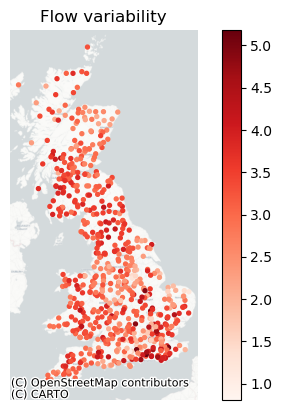

In [23]:
fig,ax=plt.subplots()
merged.plot('flow_variability', ax=ax, markersize=8, legend=True,  cmap='Reds', #edgecolor='black', linewidth=0.1,
            legend_kwds={"label":"" , "orientation": "vertical"})
ax.axis('off')
ax.set_title("Flow variability")
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

Text(0, 0.5, 'BFI')

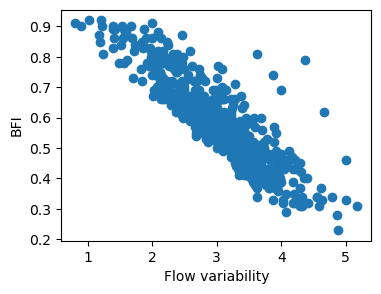

In [24]:
plt.figure(figsize=(4,3))
plt.scatter(merged['flow_variability'], merged['baseflow_index'])
plt.xlabel('Flow variability')
plt.ylabel('BFI')

In [ ]:
# fig,axs=plt.subplots(ncols=3, figsize=(10,8))
# merged.plot('q_mean', ax=axs[0], markersize=8, legend=False, cmap='Blues',
#             legend_kwds={"label": "...", "orientation": "vertical"})
# axs[0].axis('off')
# axs[0].set_title("Mean runoff")
# ctx.add_basemap(axs[0], source=ctx.providers.CartoDB.Positron)

# merged.plot('p_mean', ax=axs[1], markersize=8, legend=False,  cmap='Purples', #edgecolor='black', linewidth=0.1,
#             legend_kwds={"label": "mm / day", "orientation": "vertical"})
# axs[1].axis('off')
# axs[1].set_title("Mean precipitation (mm/day)")
# ctx.add_basemap(axs[1], source=ctx.providers.CartoDB.Positron)

# merged.plot('flow_variability', ax=axs[2], markersize=8, legend=False,  cmap='Purples', #edgecolor='black', linewidth=0.1,
#             legend_kwds={"label": "mm / day", "orientation": "vertical"})
# axs[2].axis('off')
# axs[2].set_title("Runoff variability")
# ctx.add_basemap(axs[2], source=ctx.providers.CartoDB.Positron)

# 4: Machine Learning Model

Objective: 
- Show how a Random Forest can link features to runoff sensitivity.  

Task: 
- Fit model using climate, soils, slope, groundwater, etc., and examine feature importance.

<!-- Prompts for students:

“Which catchment characteristics most influence runoff sensitivity?”

“Does the model match your intuition?” -->

Goal: 
- Connect data-driven tools to hydrological understanding.

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [26]:
X = merged[['baseflow_index']].values
# X = hydrologic_attributes[['baseflow_index']].values
y = merged['flow_variability']

linear_model = LinearRegression()
# linear_model = RandomForestRegressor()
linear_model.fit(X, y)

# Predictions
predictions = linear_model.predict(X)

# Model performance
r2_1 = r2_score(y, predictions)
rmse_1 = np.sqrt(mean_squared_error(y, predictions))

print("Climate-only model")
# print("Intercept:", model1.intercept_)
# print("Slope:", model1.coef_[0])
print("R2:", r2_1)
print("RMSE:", rmse_1)

Climate-only model
R2: 0.7723722676558553
RMSE: 0.3285591867347962


#### Join into one

In [28]:
test = pd.read_csv(home_dir + 'Catchment_Attributes/CAMELS_GB_v2_hydrometry_attributes.csv')

In [29]:
# merged = (gauge_locs_3857
#         .merge(climatic_attributes, on="gauge_id", how="left")
#         .merge(climatic_attributes, on="gauge_id", how="left")
#         .merge(hydrologic_attributes, on="gauge_id", how="left"))


merged = (topography
        .merge(climatic_attributes, on="gauge_id", how="left")
#         .merge(hydrologic_attributes, on="gauge_id", how="left")
         .merge(hydrogeology, on="gauge_id", how="left")
          .merge(landcover, on="gauge_id", how="left")
           .merge(soil, on="gauge_id", how="left")       
         )
merged['baseflow_index_ceh'] = hydrologic_attributes['baseflow_index_ceh'].copy()
merged['baseflow_index'] = hydrologic_attributes['baseflow_index'].copy()
merged['runoff_ratio'] = hydrologic_attributes['runoff_ratio'].copy()
merged['q_mean'] = hydrologic_attributes['q_mean'].copy()
merged['all_wood_mean'] = landcover['all_wood_mean'].copy()

merged['flow_variability'] = (hydrologic_attributes['Q95'] - hydrologic_attributes['Q5']) / hydrologic_attributes['q_mean']

In [31]:
test = merged.copy()
del test['gauge_id']
del test['gauge_name']
# del test['geometry']
del test['gauge_lat']
del test['gauge_lon']
del test['low_prec_timing']
del test['high_prec_timing']
del test['flow_variability']
del test['baseflow_index']
del test['baseflow_index_ceh']

In [ ]:
# test = hydrologic_attributes['Q95'] - hydrologic_attributes['Q5']
# plt.hist(test)
# hydrologic_attributes[hydrologic_attributes['gauge_id'] ==13008]
# climatic_attributes[climatic_attributes['gauge_id'] ==13008]

Baseline RMSE (predict mean): 0.702
Baseline R2 (predict mean): -0.005

Random Forest performance
R²: 0.528
RMSE: 0.481


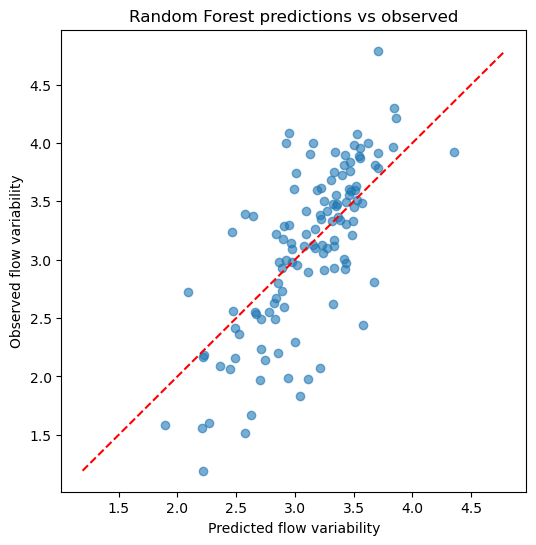

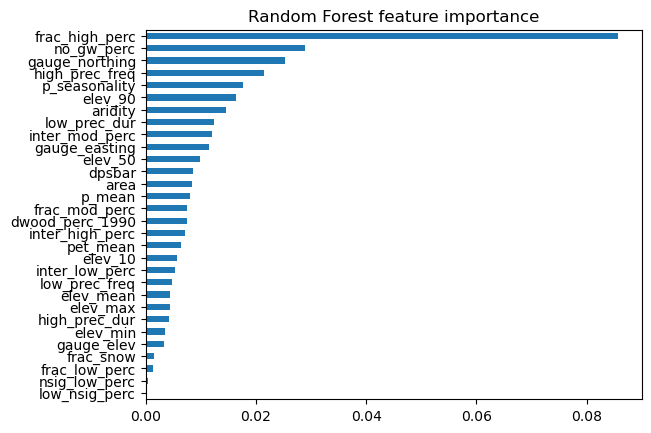

In [50]:
# -------------------------
# 1️⃣ Import libraries
# -------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# -------------------------
# 2️⃣ Define predictor variables (students can experiment here)
# -------------------------
climate_vars = ['p_mean', 'pet_mean', 'p_seasonality']        # add more from climatic_attributes
topography_vars = ['dpsbar', 'elev_mean']                 # e.g. slope_mean, elev_mean
landcover_vars = ['all_wood_mean']           # e.g. grass_mean
# hydrology_vars = ['baseflow_index']
soil_vars = []                               # e.g. clay_mean, sand_mean

# Combine predictors from different dataframes
X = pd.concat([
    climatic_attributes[climate_vars],
    topography[topography_vars],
    landcover[landcover_vars],
#     hydrologic_attributes[hydrology_vars],
    soil[soil_vars]
], axis=1)
X = test

# Response variable
y = merged['flow_variability']

# -------------------------
# 3️⃣ Clean data (remove NaNs and Infs)
# -------------------------
data = pd.concat([X, y], axis=1)
data = data.replace([np.inf, -np.inf], np.nan).dropna()

X = data[X.columns]
y = data[y.name]

# -------------------------
# 4️⃣ Split into training and test sets
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# 5️⃣ Baseline model (predict mean)
# -------------------------
baseline_pred = np.repeat(y_train.mean(), len(y_test))
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)
print("Baseline RMSE (predict mean):", round(baseline_rmse,3))
print("Baseline R2 (predict mean):", round(baseline_r2,3))

# -------------------------
# 6️⃣ Random Forest model
# -------------------------
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("\nRandom Forest performance")
print("R²:", round(r2_rf,3))
print("RMSE:", round(rmse_rf,3))


# -------------------------
# 8️⃣ Plot predicted vs observed (Random Forest example)
# -------------------------
plt.figure(figsize=(6,6))
plt.scatter(pred_rf, y_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--', color='red')
plt.xlabel("Predicted flow variability")
plt.ylabel("Observed flow variability")
plt.title("Random Forest predictions vs observed")
plt.show()

# -------------------------
# 10️⃣ Optional: feature importance (Random Forest)
# -------------------------
importances = pd.Series(rf_model.feature_importances_[:30], index=X.columns[:30])
importances.sort_values().plot.barh()
plt.title("Random Forest feature importance")
plt.show()

# Relationship between flow and precipitation
Load in datasets that we used before...  
Get dataframe with gauge locations and topographic variables